In [3]:
using SparseArrays
using LinearAlgebra
using Plots

# -----------------------
# Material parameters
# -----------------------
#E  = 1.0
#ν  = 0.3

λ = 1.0 #E*ν/(1-ν^2)          # plane stress
μ = 0.1 #E/(2*(1+ν))

# Poisson ratio
ν = λ/(2*(λ + μ))

# -----------------------
# Grid
# -----------------------
Nx = 30
Ny = 30
Lx = 1.0
Ly = 1.0
hx = Lx/(Nx-1)
hy = Ly/(Ny-1)

N = Nx*Ny
Ndof = 2*N

function idx(i,j,c)
    node = (j-1)*Nx + i
    return 2*(node-1) + c
end

rows = Int[]
cols = Int[]
vals = Float64[]
b    = zeros(Ndof)

function add(i,j,v)
    push!(rows,i)
    push!(cols,j)
    push!(vals,v)
end

ε0 = 0.1

# -----------------------
# Assembly
# -----------------------
for j in 1:Ny
for i in 1:Nx

    # -------- Left boundary (fixed) --------
    if i == 1
        for comp in 1:2
            row = idx(i,j,comp)
            add(row,row,1.0)
            b[row] = 0.0
        end
        continue
    end

    # -------- Right boundary (stretch) --------
    if i == Nx
        # a1 prescribed
        row = idx(i,j,1)
        add(row,row,1.0)
        b[row] = ε0

        # a2 free (natural already satisfied)
        row = idx(i,j,2)
        add(row,row,1.0)
        b[row] = 0.0
        continue
    end

    # -------- Bottom traction free --------
    if j == 1
        # σ_yy = 0
        row = idx(i,j,2)

        add(row, idx(i,j+1,2),  (λ+2μ)/hy)
        add(row, idx(i,j,2),   -(λ+2μ)/hy)
        add(row, idx(i+1,j,1),  λ/(2hx))
        add(row, idx(i-1,j,1), -λ/(2hx))

        # σ_xy = 0
        row = idx(i,j,1)
        add(row, idx(i,j+1,1),  μ/hy)
        add(row, idx(i,j,1),   -μ/hy)
        add(row, idx(i+1,j,2),  μ/(2hx))
        add(row, idx(i-1,j,2), -μ/(2hx))
        continue
    end

    # -------- Top traction free --------
    if j == Ny
        # σ_yy = 0
        row = idx(i,j,2)

        add(row, idx(i,j,2),    (λ+2μ)/hy)
        add(row, idx(i,j-1,2), -(λ+2μ)/hy)
        add(row, idx(i+1,j,1),  λ/(2hx))
        add(row, idx(i-1,j,1), -λ/(2hx))

        # σ_xy = 0
        row = idx(i,j,1)
        add(row, idx(i,j,1),    μ/hy)
        add(row, idx(i,j-1,1), -μ/hy)
        add(row, idx(i+1,j,2),  μ/(2hx))
        add(row, idx(i-1,j,2), -μ/(2hx))
        continue
    end

    # -------- Interior Navier equation --------
    for comp in 1:2
        row = idx(i,j,comp)

        if comp == 1
            add(row, idx(i,j,1), -2*(λ+2μ)/hx^2 - 2*μ/hy^2)
            add(row, idx(i+1,j,1),(λ+2μ)/hx^2)
            add(row, idx(i-1,j,1),(λ+2μ)/hx^2)
            add(row, idx(i,j+1,1),μ/hy^2)
            add(row, idx(i,j-1,1),μ/hy^2)

            coeff = (λ+μ)/(4hx*hy)
            add(row, idx(i+1,j+1,2),  coeff)
            add(row, idx(i+1,j-1,2), -coeff)
            add(row, idx(i-1,j+1,2), -coeff)
            add(row, idx(i-1,j-1,2),  coeff)
        else
            add(row, idx(i,j,2), -2*(λ+2μ)/hy^2 - 2*μ/hx^2)
            add(row, idx(i,j+1,2),(λ+2μ)/hy^2)
            add(row, idx(i,j-1,2),(λ+2μ)/hy^2)
            add(row, idx(i+1,j,2),μ/hx^2)
            add(row, idx(i-1,j,2),μ/hx^2)

            coeff = (λ+μ)/(4hx*hy)
            add(row, idx(i+1,j+1,1),  coeff)
            add(row, idx(i+1,j-1,1), -coeff)
            add(row, idx(i-1,j+1,1), -coeff)
            add(row, idx(i-1,j-1,1),  coeff)
        end
    end

end
end

M = sparse(rows,cols,vals,Ndof,Ndof)

u = M \ b

a1 = reshape(u[1:2:end],Nx,Ny)
a2 = reshape(u[2:2:end],Nx,Ny)

30×30 Matrix{Float64}:
 0.0        0.0        0.0         …   0.0          0.0         0.0
 0.0178486  0.0125449  0.00938615     -0.00938615  -0.0125449  -0.0178486
 0.0188057  0.0171141  0.0145908      -0.0145908   -0.0171141  -0.0188057
 0.0259709  0.0230493  0.0202437      -0.0202437   -0.0230493  -0.0259709
 0.0293059  0.027099   0.0244777      -0.0244777   -0.027099   -0.0293059
 0.0333908  0.0309585  0.0283067   …  -0.0283067   -0.0309585  -0.0333908
 0.036326   0.0340334  0.0314271      -0.0314271   -0.0340334  -0.036326
 0.0390478  0.0367009  0.0340885      -0.0340885   -0.0367009  -0.0390478
 0.0412225  0.0388857  0.0362758      -0.0362758   -0.0388857  -0.0412225
 0.0430623  0.0406948  0.0380739      -0.0380739   -0.0406948  -0.0430623
 0.0445261  0.0421406  0.0395093   …  -0.0395093   -0.0421406  -0.0445261
 0.0456746  0.0432654  0.0406216      -0.0406216   -0.0432654  -0.0456746
 0.0465142  0.0440877  0.0414335      -0.0414335   -0.0440877  -0.0465142
 ⋮                    

Measured Poisson ratio ≈ 0.946806952440648
Theoretical ν = 0.45454545454545453


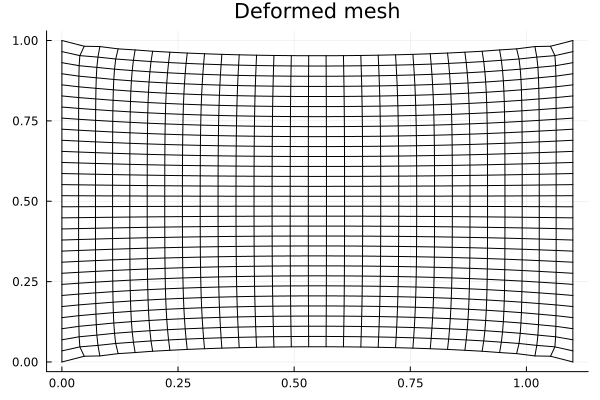

In [7]:
# -----------------------
# Check Poisson squeeze
# -----------------------
mid = div(Ny,2)
εx = (a1[end,mid] - a1[1,mid]) / Lx
εy = (a2[mid,Ny] - a2[mid,1]) / Ly

println("Measured Poisson ratio ≈ ", -εy/εx)
println("Theoretical ν = ", ν)

# -----------------------
# Plot deformation
# -----------------------
x = range(0,Lx,length=Nx)
y = range(0,Ly,length=Ny)

X = [xi for xi in x, yi in y]
Y = [yi for xi in x, yi in y]

scale = 1  # exaggerate deformation for visualization

p = plot()
for j in 1:Ny
    plot!(p, X[:,j] .+ scale*a1[:,j],
              Y[:,j] .+ scale*a2[:,j],
              color=:black,
              legend=false)
end
for i in 1:Nx
    plot!(p, X[i,:] .+ scale*a1[i,:],
              Y[i,:] .+ scale*a2[i,:],
              color=:black,
              legend=false)
end

title!(p,"Deformed mesh")
display(p)